# Task 4: Predicting Insurance Claim Amounts

## Objective
Estimate medical insurance charges based on personal information using a Linear Regression model.

## 1. Import Required Libraries

In [23]:
# Import libraries for data analysis, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the Dataset

In [24]:
# Load the insurance dataset
df = pd.read_csv('insurance.csv')

# Display the first five rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Understand the Dataset

In [25]:
# Display the shape and columns of the dataset
print('Shape of Dataset:', df.shape)
print('\nColumns:')
print(df.columns)

# Display information about the dataset
df.info()

Shape of Dataset: (1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## 4. Check Missing Values and Summary Statistics

In [26]:
# Check for missing values
print(df.isnull().sum())

# Display summary statistics
df.describe()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 5. Exploratory Data Analysis (EDA)

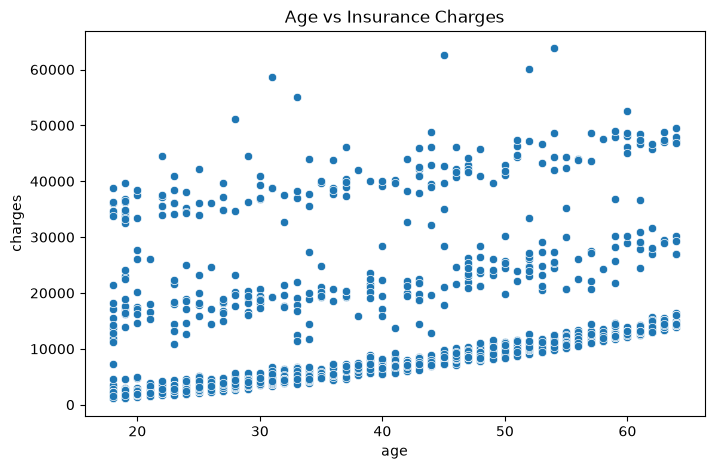

In [27]:
# Visualize the relationship between age and insurance charges
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='charges')
plt.title('Age vs Insurance Charges')
plt.show()

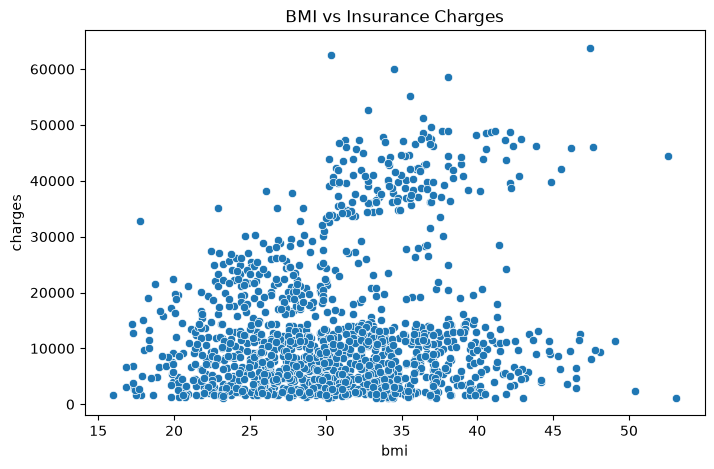

In [28]:
# Visualize the relationship between BMI and insurance charges
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('BMI vs Insurance Charges')
plt.show()

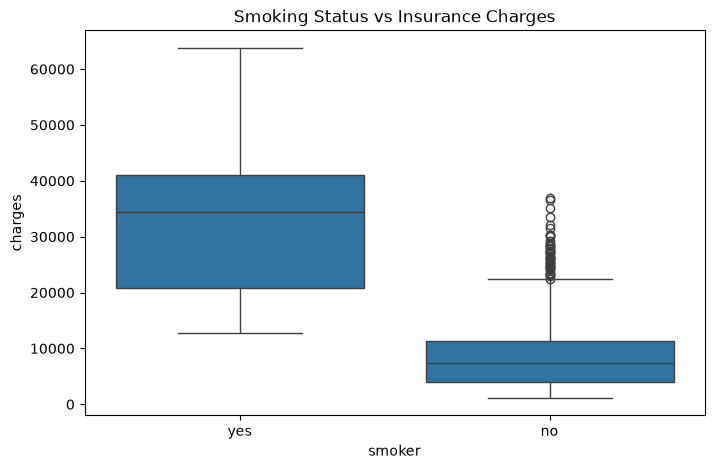

In [29]:
# Visualize the impact of smoking status on insurance charges
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Smoking Status vs Insurance Charges')
plt.show()

## 6. Encode Categorical Variables

In [30]:
# Convert categorical columns into numeric values
encoder = LabelEncoder()

for column in ['sex', 'smoker', 'region']:
    df[column] = encoder.fit_transform(df[column])

# Display the updated dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## 7. Prepare Data for Modeling

In [31]:
# Separate features and target variable
X = df.drop('charges', axis=1)
y = df['charges']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training Data Shape:', X_train.shape)
print('Testing Data Shape:', X_test.shape)

Training Data Shape: (1070, 6)
Testing Data Shape: (268, 6)


## 8. Train the Linear Regression Model

In [32]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict insurance charges
y_pred = model.predict(X_test)

## 9. Evaluate the Model

In [33]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print('Mean Absolute Error (MAE):', mae)
print('Root Mean Squared Error (RMSE):', rmse)
print('R² Score:', r2)

Mean Absolute Error (MAE): 4186.508898366432
Root Mean Squared Error (RMSE): 5799.587091438356
R² Score: 0.7833463107364539


# Conclusion

- The insurance dataset was explored and cleaned.
- A Linear Regression model was trained to predict insurance charges.
- Age, BMI, and smoking status significantly influence medical costs.
- The model was evaluated using MAE, RMSE, and R² score.
